In [282]:
import re
import json
import easyocr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import os

In [283]:
def clean_text(text):
    return ''.join(c for c in text if c.isprintable() and not (0xD800 <= ord(c) <= 0xDFFF))


In [284]:
def load_json_config(json_filename):
    path = os.path.join("templates", json_filename)
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

In [285]:
def detect_card_type(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ['income tax department', 'permanent account number', 'govt. of india', 'signature', 'permanent account number card','govt of india']):
        return 'pan'
    elif any(x in joined_text for x in ['aadhaar', 'uidai', 'government of india','unique identification authority of india','government oi india','address']):
        return 'aadhaar'
    return 'unknown'

In [286]:
def detect_pan_format(text_lines):
    pan_idx = -1
    dob_idx = -1
    for i, line in enumerate(text_lines):
        if re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line):
            pan_idx = i
        if re.search(r'\d{2}/\d{2}/\d{4}', line):
            dob_idx = i
    return 'pan_format1.json' if pan_idx < dob_idx else 'pan_format2.json'

In [287]:
def detect_aadhaar_format(text_lines):
    joined_text = ' '.join([line.lower() for line in text_lines])
    if any(x in joined_text for x in ["address", "s/o", "d/o", "w/o", "c/o", "पताः", "पता"]):
        return 'aadhaar_back.json'
    return 'aadhaar_front.json'


In [288]:
def extract_pan_number(text_lines):
    for line in text_lines:
        match = re.search(r'\b[A-Z]{5}[0-9]{4}[A-Z]\b', line)
        if match:
            return match.group().strip()
    return None


In [289]:
def extract_pan_by_config(text_lines, config):
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if heading.lower() in line.lower()]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type in ["pattern", "date"]:
            regex = pattern.replace("C", "[A-Z]").replace("N", "[0-9]")
            for line in text_lines:
                match = re.search(regex, line)
                if match:
                    extracted[key] = clean_text(match.group().strip())
                    break
        elif format_type == "line_relative":
            for idx in heading_lines:
                new_idx = idx + line_offset if direction == "down" else idx - line_offset
                if 0 <= new_idx < len(text_lines):
                    extracted[key] = clean_text(text_lines[new_idx].strip().upper())
                    break
    return extracted

In [290]:
def extract_aadhaar_by_config(text_lines, config):
    extracted = {}
    for key, rule in config.items():
        heading = rule.get('heading', "")
        direction = rule.get('direction')
        format_type = rule.get('format')
        pattern = rule.get('pattern', "")
        line_offset = rule.get('line_offset', 1)
        keywords = rule.get('keywords', [])

        heading_lines = []
        if isinstance(heading, list):
            heading_lines = [i for i, line in enumerate(text_lines) if any(h.lower() in line.lower() for h in heading)]
        elif heading:
            heading_lines = [i for i, line in enumerate(text_lines) if re.search(heading, line, re.IGNORECASE)]
        else:
            heading_lines = list(range(len(text_lines)))

        if format_type == "regex":
            for line in text_lines:
                match = re.search(pattern, line, re.IGNORECASE)  # Added re.IGNORECASE here
                if match:
                    extracted[key] = clean_text(match.group(1).strip() if match.groups() else match.group().strip().upper())
                    break

        elif format_type == "keyword":
            for line in text_lines:
                for keyword in keywords:
                    if keyword.lower() in line.lower():
                        extracted[key] = keyword
                        break

        elif format_type == "line_relative":
            if not isinstance(line_offset, list):
                line_offset = [line_offset]

            if key == "Person_Name":
                for idx in heading_lines:
                    for offset in line_offset:
                        new_idx = idx - offset
                        while new_idx >= 0:
                            text = text_lines[new_idx].strip().upper()
                            if not re.search(r'[A-Za-z]', text) or re.search(r'[^A-Za-z\s]', text):
                                new_idx -= 1
                                continue
                            if 2 <= len(text.split()) <= 5:
                                extracted[key] = clean_text(text)
                                break
                            new_idx -= 1
                        if key in extracted:
                            break
            else:
                for idx in heading_lines:
                    for offset in line_offset:
                        new_idx = idx + offset if direction == "down" else idx - offset
                        if 0 <= new_idx < len(text_lines):
                            extracted[key] = clean_text(text_lines[new_idx].strip().upper())
                            break

        elif format_type == "block" and direction == "below":
            for idx in heading_lines:
                block_lines = []
                seen_lines = set()
                for j in range(idx + 1, len(text_lines)):
                    line = clean_text(text_lines[j].strip())

                    if re.search(r'\d{4}\s?\d{4}\s?\d{4}', line) or len(re.findall(r'\d{6}', line)) >= 2:
                        break
                    if len(re.findall(r'\d', line)) > 10:
                        continue
                    if re.search(r'[\u0900-\u097F]', line) or len(line) <= 2:
                        continue
                    if any(x in line.lower() for x in ["uidai", "help", "toll", "visit", ".in", "gov", "www"]):
                        continue

                    cleaned = re.sub(r'[^\w\s,/-]', '', line)
                    if cleaned.lower() in seen_lines:
                        continue
                    seen_lines.add(cleaned.lower())
                    block_lines.append(cleaned)

                if block_lines:
                    extracted[key] = clean_text(' '.join(block_lines).strip().upper())
                    break

    return extracted

In [291]:
def pan_details_extraction(text_lines, config):
    extracted = extract_pan_by_config(text_lines, config)
    pan_number = extract_pan_number(text_lines)
    if pan_number:
        extracted["PAN_No"] = clean_text(pan_number)
    return extracted

In [292]:
def aadhaar_details_extraction(text_lines, config):
    extracted = extract_aadhaar_by_config(text_lines, config)
    return extracted

In [293]:
def display_with_boxes(image_path, results):
    image = Image.open(image_path)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(image)
    for (bbox, text, _) in results:
        (top_left, top_right, bottom_right, bottom_left) = bbox
        x, y = top_left
        width = top_right[0] - top_left[0]
        height = bottom_left[1] - top_left[1]
        if height > width * 2:
            continue
        if re.search(r'[\u0900-\u097F]', text):
            continue
        rect = Rectangle((x, y), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, clean_text(text), fontsize=10, color='blue', backgroundcolor='white')
    plt.axis('off')
    plt.title("Detected Text and Bounding Boxes")
    plt.show()

In [294]:
reader = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


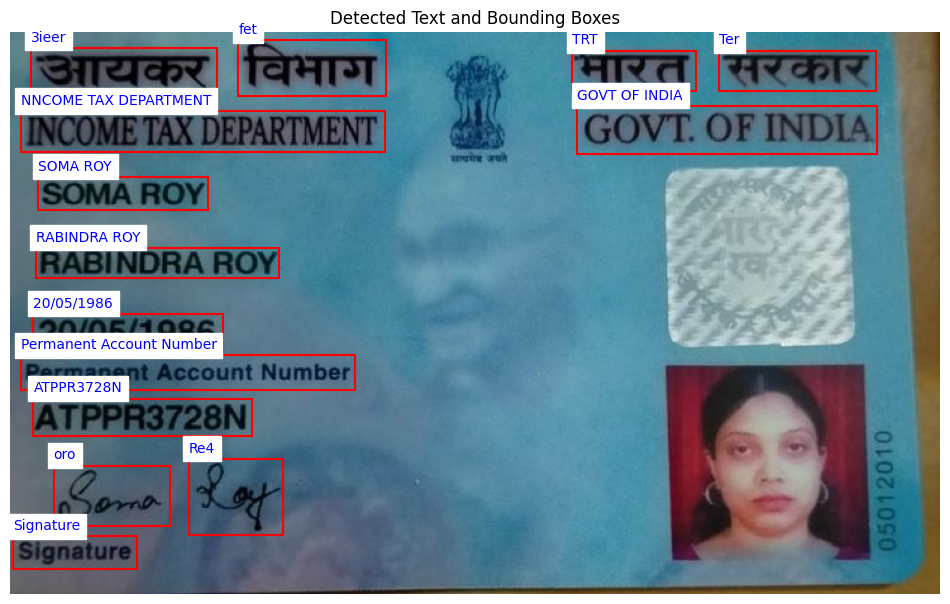

['3ieer', 'fet', 'TRT', 'Ter', 'NNCOME TAX DEPARTMENT', 'GOVT OF INDIA', 'SOMA ROY', 'RABINDRA ROY', '20/05/1986', 'Permanent Account Number', 'ATPPR3728N', 'oro', 'Re4', '1', 'Signature']

📄 Card Type: PAN
🧾 Format Used: pan_format2.json

🔍 Extracted Details:
Person_Name: SOMA ROY
Father_Name: RABINDRA ROY
DOB: 20/05/1986
PAN_No: ATPPR3728N


In [300]:
def run_ocr_pipeline(image_path):
    results = reader.readtext(image_path)
    if not results:
        print("No text detected.")
        return
    display_with_boxes(image_path, results)
    text_lines = []
    for (_, text, _) in results:
        text = clean_text(text)
        if not re.search(r'[\u0900-\u097F]', text):
            text_lines.append(text)
    print(text_lines)
    card_type = detect_card_type(text_lines)
    if card_type == 'pan':
        json_file = detect_pan_format(text_lines)
        config = load_json_config(json_file)
        extracted = pan_details_extraction(text_lines, config)
    elif card_type == 'aadhaar':
        json_file = detect_aadhaar_format(text_lines)
        config = load_json_config(json_file)
        is_front = json_file == 'aadhaar_front.json'
        extracted = aadhaar_details_extraction(text_lines, config)
    else:
        print(json.dumps({"error": "Unable to determine card type"}, indent=2))
        return
    print(f"\n📄 Card Type: {card_type.upper()}")
    print(f"🧾 Format Used: {json_file}\n")
    if not extracted:
        print("No details extracted.")
    else:
        print("🔍 Extracted Details:")
        for key, value in extracted.items():
            print(f"{key}: {value}")

if __name__ == "__main__":
    image_path = "pancard/10.png" 
    run_ocr_pipeline(image_path)
